# Introduction


As part of the examination for the course DLMDSPWP01 – Programming with Python, I developed a Python project and a Jupyter Notebook. The goal of the project is to use training datasets to identify the best-fitting ideal functions (based on the Least Squares criterion) from a set of 50 provided functions. Afterwards, test data points are assigned to the selected ideal functions, under the constraint of a maximum allowed deviation.

The project is designed with an object-oriented approach. I created five classes (`BaseManager`, `LogicManager`, `VisualManager`, `DatabaseManager`, `UnitTestManager`) to separate different tasks and improve code readability. I reworked the project into this fully functional Jupyter Notebook and additionally provide a GitHub repository containing both the Jupyter Notebook and the standalone project, which can be run with IDEs like Visual Studio Code.

At the end, the project generates a visualization that displays all data points and their assignment to the respective ideal function (if a match was found). The matched points are color-coded according to the assigned ideal function. The interactive version can be viewed for more detail after running the whole Jupyter Notebook. For this PDF export a none interactive version is added to give an idea of the result after running the whole notebook. 

**Important**: The CSV files must be placed in a `data` subfolder for the program to work, or the file paths must be adjusted manually in the **Imports and Global Values** section.

The complete source code is available in the following [GitHub Repository](https://github.com/WilliamRatz/PythonModule)


# Imports and Global Values


The following imports are needed for the Manager classes and the final main function.

The value `unit_testing` enables unit testing before performing the whole task. When at leasts one unit test fails the program will be terminated.

The value `csv_location` has to be set to where the csv files (`ideal.csv`, `train.csv` and `test.csv`) are located, so they can be used through the program.


In [1]:
import os
import pandas as pd
import numpy as np
import sqlalchemy as db
from typing import Tuple, Optional
from IPython.display import Image, display

from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, GlyphRenderer
from bokeh.models import HoverTool, Legend, LegendItem
from bokeh.colors import RGB

# Enable or disable unit testing.
unit_testing = True
# Define the location of the csv data.
csv_location = os.path.abspath("./data/")
# Define that the rsult plot will be
# displayed in the end of this notebook
output_notebook()

Loading BokehJS ...

# BaseManager Class


## Class Explanation


The `BaseManager` class provides shared functionality such as status tracking and basic logging. It acts as a lightweight superclass for other managers. Allowing consistent monitoring of each component's internal state via direct request or passively while logging.


## Purpose and Functions


### \_\_init\_\_(...)


Initializes the `BaseManager`:

- Sets the default internal status to `CREATED`.
- Prepares the class to use status updates and logging.


### log(...)


Logs a message to the console in a standardized format:

- Includes the class name and its current status in the output.
- Useful for tracing execution flow and debugging during development.


### set_status(...)


Updates the current internal status string:

- Used by subclasses to reflect key processing stages (e.g., `INITIALIZED`, `RENDERING`)


### status (property)


Returns the current status value:

- Allows clean, read-only access to the status without exposing the internal \_status variable.


In [2]:
class BaseManager:
    """Base class providing common functionality to all managers."""

    def __init__(self) -> None:
        """
        Initialization the BaseManager
        """
        # Initiate the default status value.
        self._status = "CREATED"

    def log(self, message) -> None:
        """
        The basic logging functionality.

        :param message: Message to log in consol.
        """

        # Print the message including the current status of the manager.
        print(f"[{self.__class__.__name__} : {self.status}]: {message}")

    def set_status(self, status) -> None:
        """
        Changing the status of the class.
        """
        self._status = status

    @property
    def status(self) -> str:
        return self._status

---


# LogicManager Class


## Class Explanation


The `LogicManager` class implements the core mathematical logic of the application, including function fitting, deviation calculation, and test data validation.

This class is separated from the database or visualization components to follow clean object-oriented principles and to keep a clear separation of concerns. It is designed to work on in-memory data structures, particularly `pandas.DataFrame` objects and supports several core functionalities.

It inherits from `BaseManager`, which gives it access to standardized status tracking and logging features. These are used throughout the class to report validation errors and processing stages, supporting transparency and easier debugging.


## Purpose and Functions


### get_best_fit_function(...)


This method identifies the best-fitting ideal function for a given training function.

- It computes the least squares deviation between the training data and each of the 50 ideal functions.
- The ideal function with the smallest sum of squared y-deviations is selected and its index returned.


### calculate_max_deviation(...)


This function calculates the largest y-difference between training data and an ideal function at matching x-values.

- Sets the max allowed deviation (used with √2 scaling) for test data mapping.
- Ensures test points stay within valid bounds.


### validate_deviation(...)


This method checks if a specific (x, y) test data point can be assigned to a given ideal function.

- It locates the closest point on the ideal function and measures the Euclidean distance.
- If the distance is within the allowed threshold, it returns the deviation; otherwise, it returns None.


### find_best_function_test(...)


This high-level method checks a test data point against all ideal functions selected during training.

- It determines whether the point fits any of the ideal functions within the allowed deviation.
- If multiple ideal functions are possible, the one with the smallest deviation is chosen.


In [3]:
class LogicManager(BaseManager):

    def __init__(self) -> None:
        """
        Initialization of the LogicManager.
        """
        # Initialize the parent class.
        super().__init__()

        # Change the status to "INITIALIZED".
        self.set_status("INITIALIZED")

    def get_best_fit_function(
        self, xy_train_func: pd.DataFrame, 
        xy_all_ideal_func: pd.DataFrame
    ) -> int:
        """
        Find the best fitting ideal function for a train function.

        :param xy_train_func: a train function
        :param xy_all_ideal_func: all possible ideal functions
        :return: index of best fitting function
        """
        # Check for empty data.
        if xy_train_func.empty or xy_all_ideal_func.empty:
            error_msg = "Input DataFrames cannot be empty."
            # Change the status to "ERROR".
            self.set_status("ERROR")
            # Log the error message.
            self.log(f"Validation failed: {error_msg}")
            raise ValueError(error_msg)

        # Verify required columns exist.
        if len(xy_train_func.columns) < 2 or len(xy_all_ideal_func.columns) < 2:
            error_msg = "DataFrames must contain at least X and Y columns."
            # Change the status to "ERROR".
            self.set_status("ERROR")
            # Log the error message.
            self.log(f"Validation failed: {error_msg}")
            raise ValueError(error_msg)

        # Ensure x values match.
        if not np.array_equal(
            xy_train_func.iloc[:, 0].values, 
            xy_all_ideal_func.iloc[:, 0].values
        ):
            error_msg = "X values in training and ideal datasets do not match."
            # Change the status to "ERROR".
            self.set_status("ERROR")
            # Log the error message.
            self.log(f"Validation failed: {error_msg}")
            raise ValueError(error_msg)

        y_train = xy_train_func.iloc[:, 1].values
        best_function = -1
        smallest_deviation = float("inf")

        # Check each Y column (skip X column at index 0).
        for column in range(1, len(xy_all_ideal_func.columns)):
            y_ideal = xy_all_ideal_func.iloc[:, column].values
            deviation = np.sum((y_train - y_ideal) ** 2)

            if deviation < smallest_deviation:
                smallest_deviation = deviation
                best_function = column

        return best_function

    def calculate_max_deviation(
        self, xy_train: pd.DataFrame, 
        xy_ideal: pd.DataFrame
    ) -> float:
        """
        Calculate the maximum Y deviation between training data and ideal
        function at matching X values.

        :param xy_train: DataFrame with (x, y) coordinates of the training data
        :param xy_ideal: DataFrame with (x, y) coordinates of the ideal function
        :return: Maximum absolute Y deviation
        """
        # Ensure the x-values match.
        if not np.allclose(xy_train.iloc[:, 0], xy_ideal.iloc[:, 0], atol=1e-6):
            error_msg = "X values in training and ideal datasets do not match"
            # Change the status to "ERROR".
            self.set_status("ERROR")
            # Log the error message.
            self.log(f"Validation failed: {error_msg}")
            raise ValueError(error_msg)

        # Compute the absolute differences in y-values.
        y_diff = np.abs(xy_train.iloc[:, 1] - xy_ideal.iloc[:, 1])

        # Return the maximum deviation.
        return y_diff.max()

    def validate_deviation(
        self, x_value, y_value, 
        xy_func: pd.DataFrame, max_deviation
    ) -> Optional[float]:
        """
        Validate if the (x,y) coordinate fits within the maximum deviation
        from the ideal function at the given x position.

        :param x_value: x value of coordinate
        :param y_value: y value of coordinate
        :param xy_func: ideal function to validate against
        :param max_deviation: maximum allowed deviation
        :return: deviation if validated, otherwise None
        """
        # Try to find the exact matching x_value in the ideal function.
        match = xy_func.loc[np.isclose(xy_func.iloc[:, 0], x_value, atol=1e-6)]

        if match.empty:
            # No matching x found (should normally not 
            # happen if x-values match).
            return None

        # Get corresponding y from the ideal function.
        y_value_func = match.iloc[0, 1]

        # Calculate vertical deviation (only y-axis, since x is matched).
        deviation = np.abs(y_value - y_value_func)

        if deviation <= max_deviation:
            return deviation

        # Deviation too large.
        return None

    def find_best_function_test(
        self,
        x_value,
        y_value,
        dataFrame_ideal: pd.DataFrame,
        pd_func_max_div: pd.DataFrame,
    ) -> Tuple[Optional[float], Optional[int]]:
        """
        Validate if the (x,y) coordiate fit into the max_deviation
        of the xy_func.

        :param x_value: x value of coordinate
        :param y_value: y value of coordinate
        :param dataFrame_ideal: all ideal function
        :param pd_func_max_div: array with (choosen function, max deviation)
        :return: returns best deviation and the best fitting function
        """

        best_deviation = None
        best_function = None

        # Loop over all functions.
        for index, row in pd_func_max_div.iterrows():
            func_id = row["func_id"]
            max_div = row["max_div"]

            deviation = self.validate_deviation(
                x_value, y_value, 
                dataFrame_ideal.iloc[:, [0, func_id]], 
                max_div
            )

            # Check if the result is the better option.
            if deviation != None:
                if best_deviation == None or deviation < best_deviation:
                    best_deviation = deviation
                    best_function = func_id

        # Return the solution.
        return best_deviation, best_function

---


# VisualManager Class


## Class Explanation


The `VisualManager` class is responsible for creating a comprehensive and meaningful visualization of all data involved in the task. Including training data, ideal functions, test data and the deviations between them.

This class focuses purely on data visualization, separating visual concerns from database handling and logical processing (as done by the `DatabaseManager` and `LogicManager` classes). It makes use of the `Bokeh` library for rendering and is designed to support clarity, reproducibility and visual insight into the data and its relations.

It inherits from `BaseManager`, which gives it access to standardized status tracking and logging features. These are used throughout the class to report validation errors and processing stages, supporting transparency and easier debugging.


## Purpose and Functions


### \_\_init\_\_(...)


Initializes the visual manager:

- Receives all relevant datasets (`train`, `ideal`, `test`) as pandas DataFrames
- Calls the base manager’s constructor.
- Sets the internal status state to `INITIALIZED` for lifecycle tracking.


### visualize_data_and_deviations(...)


Creates and renders an interactive `Bokeh` plot containing:

- Chosen ideal functions and their deviation ranges.
- Matched and unmatched test data points.
- Training data.
- A structured legend with section titles (via invisible placeholders).
- Interactive tooltips (type, coordinates, function)

This method also tracks internal status changes (`PLOT_GENERATION`, `RENDERING`, `IDLE`) using the inherited state logic, ensuring traceable execution flow.


### darken_color(...)


Helper method that modifies a color (hex) to a darker shade.

- Used to visually differentiate matched test points from their corresponding ideal function bands.


### \_plot_ideal_functions(...)


Plots ideal functions with vertical deviation zones (y ± `max_deviation`) as shaded bands.

- The chosen functions are highlighted with thicker lines and shaded deviation areas.
- Shows exact √2-scaled tolerance from training data.
- The unchosen functions are plotted in semi-transparent gray.
- Returns `Bokeh` `LegendItem` entries for inclusion in a custom legend.


### \_plot_training_data(...)


Plots all training data points using gray scatter dots with low opacity.

- Helps to visually indicate how densely the training data covers the function space.
- Returns the renderer for legend integration.


### \_plot_test_data(...)


Plots the test dataset with matched and unmatched coloring:

- Matched test points are shown using slightly darkened colors of their corresponding function colors.
- Unmatched test points are shown in gray.
- All points include metadata for tooltips (`type`, `x`, `y`, `function`)
- Returns labeled renderer tuples for dynamic legend creation.


In [4]:
class VisualManager(BaseManager):
    def __init__(
        self, df_train: pd.DataFrame, 
        df_ideal: pd.DataFrame, 
        df_test: pd.DataFrame
    ) -> None:
        """
        Initialize with dataframes and Bokeh configuration

        :param df_train: train DataFrame
        :param df_ideal: ideal DataFrame
        :param df_test: test DataFrame
        """
        # Initialize parent class.
        super().__init__()

        # Store the train DataFrame.
        self.dataFrame_train = df_train
        # Store the ideal DataFrame.
        self.dataFrame_ideal = df_ideal
        # Store the test DataFrame.
        self.dataFrame_test = df_test

        # Change the status to "INITIALIZED".
        self.set_status("INITIALIZED")

    def visualize_data_and_deviations(
        self, func_dev_df: pd.DataFrame, func_colors: list[str]
    ) -> None:
        """
        Creation of an interactive visualization.

        :param func_dev_df: DataFrame with chosen functions and their deviations
        :param func_colors: List of colors for each function
        """

        # Change the status to "PLOT_GENERATION".
        self.set_status("PLOT_GENERATION")

        # Create the main figure.
        p = figure(
            title="Data Visualization with Deviation Areas",
            width=1100,
            height=900,
            x_range=(-20, 20),
            y_range=(-40, 40),
            tools="pan,wheel_zoom,box_zoom,reset,save",
            toolbar_location="above",
        )

        # Add the grid and axis label.
        p.grid.grid_line_alpha = 0.3
        p.xaxis.axis_label = "X"
        p.yaxis.axis_label = "Y"

        # Create a variable for the legend items.
        legend_items = []

        # Creation of a renderer to enable titels in the legend.
        # There is no other possiblity in Bokeh.
        dummy_renderer = p.scatter(
            x=[9999], y=[9999], size=0, alpha=0, marker="circle", visible=False
        )

        # Add a legend titel for chosen functions.
        legend_items.append(
            LegendItem(label="--- Chosen Functions ---",
                       renderers=[dummy_renderer])
        )

        # Plot the ideal functions.
        # Add the ideal functions to the legend.
        legend_items += self._plot_ideal_functions(p, func_dev_df, func_colors)

        # Add a legend titel for test data.
        legend_items.append(
            LegendItem(label="--- Test Data ---", 
                       renderers=[dummy_renderer])
        )

        # Plot the test data.
        for label, renderer in self._plot_test_data(
            p, func_dev_df["func_id"], func_colors
        ):
            # Add the test data to the legend.
            legend_items.append(LegendItem(label=label, 
                                           renderers=[renderer]))

        # Add a legend titel for others.
        legend_items.append(
            LegendItem(label="--- Others ---", 
                       renderers=[dummy_renderer])
        )

        # Plot the training data.
        # Add the training data to the legend.
        legend_items.append(
            LegendItem(label="Training Data", 
                       renderers=[self._plot_training_data(p)])
        )

        # Filling of the legend with all items.
        legend = Legend(items=legend_items)

        # Set the font size of the text inside the legend.
        legend.label_text_font_size = "10pt"

        # Remove the default legend from Bokeh.
        p.legend.visible = False

        # Add the custom legend next to the plot.
        p.add_layout(legend, "right")

        # Add a hover possibility.
        hover = HoverTool(
            tooltips=[
                ("Type", "@type"),
                ("X", "@x"),
                ("Y", "@y"),
                ("Function", "@func"),
            ]
        )
        p.add_tools(hover)

        # Change the status to "RENDERING".
        self.set_status("RENDERING")

        # Visualize the whole plot.
        show(p)

        # Change the status to "IDLE".
        self.set_status("IDLE")

    def darken_color(self, hex_color: str, factor: float) -> str:
        """
        Convert hex color to a darker version

        :param hex_color: Hex color code
        :param factor: Multiplier factor
        :return: Changed color
        """
        # Convert hex color to RGB tuple.
        rgb = RGB.from_hex_string(hex_color)

        # Darken the color by multiplying each component by the factor.
        r = int(rgb.r * factor)
        g = int(rgb.g * factor)
        b = int(rgb.b * factor)

        darkened = RGB(r, g, b)

        # Return darkened hex color.
        return darkened.to_hex()

    def _plot_ideal_functions(self, plot, func_dev_df, func_colors) -> list:
        """
        Plot the ideal functions with its deviation bands.

        :param plot: The plot object where the functions will be visualized.
        :param func_dev_df: DataFrame containing the maximum deviation 
         for each function.
        :param func_colors: List of colors to use for each function's plot.
        :return: List of legend items.
        """

        # Extract the X values from the ideal data.
        x = self.dataFrame_ideal["X"].values

        # List to store the legend items.
        legend_items = []

        # Loop through each function (except the first column).
        for i in range(1, len(self.dataFrame_ideal.columns)):
            # Extract Y values for the function.
            y = self.dataFrame_ideal.iloc[:, i].values

            # The function ID is the column index.
            func_id = i

            # Check if this function has deviation data.
            if func_id in func_dev_df["func_id"].values:
                # Find the index of the function in the deviation DataFrame.
                idx = func_dev_df[func_dev_df["func_id"] == func_id].index[0]

                # Get the max deviation value for this function.
                max_dev = func_dev_df["max_div"].iat[idx]

                # Get the color for the function.
                color = func_colors[idx]

                # Reverse X values for the band.
                band_x = np.append(x, x[::-1])

                # Create the Y values for the deviation band.
                band_y = np.append(y + max_dev, (y - max_dev)[::-1])

                # Plot the function line.
                line_renderer = plot.line(x, y, line_width=2, line_color=color)

                # Plot the deviation range.
                patch_renderer = plot.patch(
                    band_x, band_y, 
                    fill_color=color, 
                    fill_alpha=0.2, 
                    line_alpha=0
                )

                # Append text for the legend.
                legend_items.append(
                    LegendItem(
                        label=f"Function {func_id}",
                        renderers=[patch_renderer, line_renderer],
                    )
                )
            else:
                # Plot the unchosen functions.
                plot.line(x, y, line_width=1, line_color="gray", line_alpha=0.2)

        # Return the list of legend items.
        return legend_items

    def _plot_training_data(self, plot) -> GlyphRenderer:
        """
        Scatters all the trainings data in gray and low alpha.

        :param plot: The plot object where the training data will be visualized.
        :return: Renderer of the scatter.
        """

        # Creation of the source object to hover.
        source = ColumnDataSource(data={"x": [], "y": [], "type": []})

        # Loop through each column in the training DataFrame.
        for col in self.dataFrame_train.columns[1:]:

            # Extraact data to visualize on plot.
            new_data = {
                "x": self.dataFrame_train["X"].values,
                "y": self.dataFrame_train[col].values,
                "type": ["Training Data"] * len(self.dataFrame_train),
            }

            # Add the new data to the data source.
            source.stream(new_data)

        # Scatter the training data.
        renderer = plot.scatter(
            "x",
            "y",
            source=source,
            size=5,
            alpha=0.3,
            color="gray",
            legend_label="Training Data",
            marker="circle",
        )

        # Return the renderer.
        return renderer

    def _plot_test_data(self, plot, chosen_functions, func_colors) -> list:
        """
        Plot test data with matched/unmatched coloring based on 
        ideal function matches.

        :param plot: The plot object where the test data will be visualized.
        :param chosen_functions: List of function IDs that are chosen as 
         ideal functions.
        :param func_colors: List of colors corresponding to each function 
         for visualization.
        :return: List of legend items.
        """
        # List to store legend items for matched/unmatched data.
        legend_items = []

        # Loop through each chosen function to plot matched test data points.
        for i, func_id in enumerate(chosen_functions):
            # Mask for the test data points matching the current function.
            mask = self.dataFrame_test["No. of ideal func"] == func_id

            # Get matched test data.
            df_matched = self.dataFrame_test[mask]

            # Create a data source for matched points.
            source = ColumnDataSource(
                data={
                    "x": df_matched["X (test func)"],
                    "y": df_matched["Y (test func)"],
                    "type": ["Matched Test Data"] * len(df_matched),
                    "func": [f"Function {func_id}"] * len(df_matched),
                }
            )

            # Scatter matched test data points.
            renderer = plot.scatter(
                "x",
                "y",
                source=source,
                size=8,
                # Darken the function color.
                color=self.darken_color(func_colors[i], 0.9),
                legend_label=f"Matched to {func_id}",
                marker="circle",
            )

            # Add to the legend.
            legend_items.append((f"Test Data matched to Func. {func_id}", 
                                 renderer))

        # Extract the unmatched test data points that don't correspond to any ideal function.
        unmatched = self.dataFrame_test[
                        self.dataFrame_test["No. of ideal func"].isna()
                        ]

        # Create a data source for the unmatched points.
        unmatched_source = ColumnDataSource(
            data={
                "x": unmatched["X (test func)"],
                "y": unmatched["Y (test func)"],
                "type": ["Unmatched Test Data"] * len(unmatched),
                "func": ["None"] * len(unmatched),
            }
        )

        # Scatter the unmatched test data points.
        unmatched_renderer = plot.scatter(
            "x",
            "y",
            source=unmatched_source,
            size=8,
            color="#898f8b",
            legend_label="Unmatched Test Data",
            marker="circle",
        )

        # Add to the legend.
        legend_items.append(("Unmatched Test Data", unmatched_renderer))

        # Return the list of legend items for test data.
        return legend_items

---


# DatabaseManager Class


## Class Explanation


The `DatabaseManager` class is responsible for handling all database-related operations in the program. Its main purpose is to ensure that training data, ideal functions and test results are correctly read from CSV files, stored in a `SQLite` database and later retrieved when needed for processing or visualization.

This class acts as the data backbone of the entire solution. It uses the `SQLAlchemy` library to interface with a relational `SQLite` database and pandas for data manipulation. By centralizing all database logic into one place, it ensures maintainability, reusability and separation of concerns.

It inherits from `BaseManager`, which gives it access to standardized status tracking and logging features. These are used throughout the class to report validation errors and processing stages, supporting transparency and easier debugging.


## Purpose and Functions


### \_\_init\_\_(...)


Initializes the database engine using the provided path to the `SQLite` database file.

- This engine is reused across all operations to interact with the database.


### createDatabase(...)


Creates all required tables (`train_db`, `ideal_db` and `test_db`) in the database if they do not already exist.

- Each table follows the schema provided in the assignment.
- Column naming is aligned exactly with the specifications (e.g., "Y1 (training func)", "No. of ideal func", etc.).


### csv_2DArray(...)


Helper method that loads a CSV file from a given path into a `pandas.DataFrame`.


### import_trainCSV(...)


Imports training data from a CSV file into the train_db table.

- Iterates over each row and calls `trainDB_add_record(...)` to insert data.
- Returns the number of successfully inserted rows.


### import_idealCSV(...)


Imports ideal function data from a CSV file into the `ideal_db` table.

- Handles the broader structure with 50 Y columns.
- Each row is passed to `idealDB_add_record(...)`.


### trainDB_add_record(...)


Inserts a single row into the `train_db` table using parameterized SQL statements.

- Returns `True` if the insertion succeeds or `False` if an exception occurs.


### idealDB_add_record(...)


Inserts a single row into the ideal_db table with 50 ideal function values.

- Dynamically builds the SQL query and parameter list for all 50 columns.


### testDB_add_record(...)


Inserts a single test data result into the test_db table, including the x/y values, the calculated deviation and the matched ideal function number.

- Used after the logic class has completed its analysis on the test dataset.


### load_table(...)


Loads an entire table (any of the three database tables) into a `pandas.DataFrame`.

- Provides easy access to database content for downstream tasks like logic evaluation or visualization.


In [5]:
class DatabaseManager(BaseManager):

    def __init__(self, db_path) -> None:
        """
        Creats/Loads database engine.

        :param db_path: path to the database
        """
        # Initialize parent class.
        super().__init__()
        # Create engine so it can be used in the whole class.
        self.db_engine = db.create_engine(f"sqlite:///{db_path}")

    def __del__(self) -> None:
        """Close all open connections to the database."""
        self.db_engine.dispose()
        # Change the status to "DISCONNECTED".
        self.set_status("DISCONNECTED")

    def load_table(self, table_name) -> Optional[pd.DataFrame]:
        """
        Loads table into a pandas data frame.

        :param table_name: name of the table to load
        :return: panda data frame of table
        """

        table = db.Table(table_name, 
                         db.MetaData(), 
                         autoload_with=self.db_engine)

        select_statement = db.select(table)
        # Connect to database and get the table.
        with self.db_engine.connect() as connection:
            result = connection.execute(select_statement)

            # Fetch all results into a list of tuples.
            rows = result.fetchall()

            # Convert the table into a dataframe.
            column_names = table.columns.keys()
            df = pd.DataFrame(rows, columns=column_names)

            return df

    def csv_2DArray(self, directory) -> pd.DataFrame:
        """
        Read csv file into a pandas data frame.

        :param directory: directory of csv file
        :return: panda data frame of csv file
        """
        return pd.read_csv(directory)

    def import_trainCSV(self, directory) -> int:
        """
        Import the train data from the train.csv into the database.

        :param directory: directory of csv file
        :return: size of successfull added records
        """
        counter = 0
        train_df = self.csv_2DArray(directory)
        for ind in train_df.index:
            if self.trainDB_add_record(
                train_df["x"][ind],
                train_df["y1"][ind],
                train_df["y2"][ind],
                train_df["y3"][ind],
                train_df["y4"][ind],
            ):
                counter += 1

        # Return the amount of records that has been added.
        return counter

    def import_idealCSV(self, directory) -> int:
        """
        Import the ideal data from the ideal.csv into the database.

        :param directory: directory of csv file
        :return: size of successfull added records
        """
        counter = 0
        ideal_df = self.csv_2DArray(directory)
        for ind in ideal_df.index:
            x_value = ideal_df["x"][ind]
            y_values = ideal_df.loc[ind, "y1":"y50"].values
            # On success increase the counter by one.
            if self.idealDB_add_record(x_value, y_values):
                counter += 1

        # Return the amount of records that has been added.
        return counter

    def trainDB_add_record(self, x, y1, y2, y3, y4) -> bool:
        """
        Add a record to the train table in the database.

        :param x: X value
        :param y1: Y1 (training func) value
        :param y2: Y2 (training func) value
        :param y3: Y3 (training func) value
        :param y4: Y4 (training func) value
        :return: True if successful or skipped due to duplicate PK
        """
        connection = self.db_engine.connect()
        try:
            # Creation SQL statement with placeholder.
            sql = db.text(
                """
                INSERT INTO train_db 
                (`X`, 
                `Y1 (training func)`, 
                `Y2 (training func)`, 
                `Y3 (training func)`, 
                `Y4 (training func)`)
                VALUES (:x, :y1, :y2, :y3, :y4)
            """
            )

            # Parameter with input data.
            params = {"x": x, "y1": y1, "y2": y2, "y3": y3, "y4": y4}

            # Execute the SQL statement.
            connection.execute(sql, params)
            connection.commit()
            return True

        except Exception as e:
            if ("Duplicate entry" in str(e) 
                or "UNIQUE constraint failed" in str(e)):
                self.log(
                    f"Record with X={x} already exists in " 
                    "train_db, skipping insert.")
            else:
                self.log(f"Error while INSERT operation in train_db: {e}")

            connection.rollback()
            return False

        finally:
            # Close the connection.
            connection.close()

    def idealDB_add_record(self, x, y_values) -> bool:
        """
        Add a record to the train table in the database.

        :param x: X value
        :param y_values: array containing all y indexes from 1 to 50
        :return: True if successful or skipped due to duplicate PK
        """
        connection = self.db_engine.connect()
        try:
            # Create a column name string for the SQL statement.
            columns = ["`X`"] + [f"`Y{i} (ideal func)`" for i in range(1, 51)]
            column_string = ", ".join(columns)

            # Create a value placeholder.
            value_placeholders = [":x"] + [f":y{i}" for i in range(1, 51)]
            value_string = ", ".join(value_placeholders)

            # Creation of SQL statement with placeholder.
            sql = f"""
                        INSERT INTO ideal_db ({column_string}) 
                        VALUES ({value_string})
                   """

            # Parameter with input data.
            params = {"x": x}
            params.update({f"y{i+1}": y for i, y in enumerate(y_values)})

            # Execute the SQL statement.
            connection.execute(db.text(sql), params)
            connection.commit()
            return True

        except Exception as e:
            if ("Duplicate entry" in str(e) 
                or "UNIQUE constraint failed" in str(e)):
                self.log(
                    f"Record with X={x} already exists in " 
                    "ideal_db, skipping insert.")
            else:
                self.log(f"Error while INSERT operation in ideal_db: {e}")

            connection.rollback()
            return False

        finally:
            # Close the connections.
            connection.close()

    def testDB_add_record(self, x_test, y_test, delta_y_test, 
                          no_ideal_func) -> bool:
        """
        Add a record to the test table in the database.

        :param x_test: X value
        :param y_test: Y (test func) value
        :param delta_y_test: Delta Y (test func) value
        :param no_ideal_func: No. of ideal func value
        :return: True if successful or skipped due to duplicate PK
        """
        connection = self.db_engine.connect()
        try:
            # Creation of SQL statement with a placeholder.
            sql = db.text(
                """
                INSERT INTO test_db 
                (`X (test func)`, 
                `Y (test func)`, 
                `Delta Y (test func)`, 
                `No. of ideal func`)
                VALUES (:x_test, :y_test, :delta_y_test, :no_ideal_func)
            """
            )

            # Parameter with the input data.
            params = {
                "x_test": x_test,
                "y_test": y_test,
                "delta_y_test": delta_y_test,
                "no_ideal_func": no_ideal_func,
            }

            # Execute the SQL statement.
            connection.execute(sql, params)
            connection.commit()
            return True

        except Exception as e:
            if ("Duplicate entry" in str(e) 
                or "UNIQUE constraint failed" in str(e)):
                self.log(
                    f"Record with X={x_test} and Y={y_test} "
                    "already exists in test_db, skipping insert."
                )
            else:
                self.log(f"Error while INSERT operation in test_db: {e}")

            connection.rollback()
            return False

        finally:
            # Close the connections.
            connection.close()

    def createDatabase(self) -> bool:
        """
        Creates all needed database tabels at the
        choosen direction, if not already exist.

        :return: True if successfull
        """
        # Get the connection object.
        connection = self.db_engine.connect()

        # Change the status to "CONNECTED".
        self.set_status("CONNECTED")

        try:
            # Get meta data object.
            meta_data = db.MetaData()

            # Create train_db table Y1-Y4.
            y_columns = [
                db.Column(f"Y{i} (training func)", db.DOUBLE_PRECISION)
                for i in range(1, 5)
            ]

            # Combine the X coulumn with the Y1 to Y4 columns.
            train_db = db.Table(
                "train_db",
                meta_data,
                db.Column(
                    "X", 
                    db.DOUBLE_PRECISION, 
                    primary_key=True, 
                    autoincrement=False
                ),
                *y_columns,
            )

            # Create ideal_db table Y1-Y50.
            y_columns = [
                db.Column(f"Y{i} (ideal func)", db.DOUBLE_PRECISION)
                for i in range(1, 51)
            ]

            # Combine the X coulumn with the Y1 to Y50 columns.
            ideal_db = db.Table(
                "ideal_db",
                meta_data,
                db.Column(
                    "X",
                    db.DOUBLE_PRECISION,
                    primary_key=True,
                    autoincrement=False,
                    nullable=True,
                ),
                *y_columns,
            )

            # Create the test_db table.
            test_db = db.Table(
                "test_db",
                meta_data,
                db.Column(
                    "X (test func)",
                    db.DOUBLE_PRECISION,
                    primary_key=True,
                    autoincrement=False,
                    nullable=True,
                ),
                db.Column(
                    "Y (test func)",
                    db.DOUBLE_PRECISION,
                    primary_key=True,
                    autoincrement=False,
                    nullable=True,
                ),
                db.Column("Delta Y (test func)", db.DOUBLE_PRECISION),
                db.Column("No. of ideal func", db.DOUBLE_PRECISION),
            )

            # Create train_db table and stores the information in the metadata.
            meta_data.create_all(self.db_engine)

            # On success return True.
            return True

        except db.exc.IntegrityError as e:
            # Change the status to "ERROR".
            self.set_status("ERROR")
            self.log(f"IntegrityError while creating database: {e}")
            connection.rollback()
            return False
        except Exception as e:
            # Change the status to "ERROR".
            self.set_status("ERROR")
            self.log(f"Unexpected error while creating database: {e}")
            connection.rollback()
            return False

        finally:
            # Close the connection.
            connection.close()
            # Change the status to "INITIALIZED".
            self.set_status("INITIALIZED")

# UnitTestManager Class


## Class Explanation


The `UnitTestManager` class provides an automated way to test and validate the functionality of the main program components — especially the core logic (`LogicManager`) and database operations (`DatabaseManager`). It ensures that individual parts of the program behave correctly, even in edge cases or under unexpected conditions.

The class focuses on structured unit testing and result reporting, fulfilling the assignment requirement to include unit tests for critical functions.

It inherits from `BaseManager`, which gives it access to standardized status tracking and logging features. These are used throughout the class to report validation errors and processing stages, supporting transparency and easier debugging.


### \_\_init\_\_(...)


Initializes the `UnitTestManager`.

- Prepares a list to store test results.
- Defines the path for a temporary database used during testing.


### \_cleanup_database(...)


Removes any test database files (`unit_test.db`) and associated journal files.

- Ensures that all test data has been deleted correctly.


### perform_unit_tests(...)


Main entry point for running all unit tests.

- Executes tests for logic functions and database operations.
- Collects and returns the results as a list of (test name, pass/fail) tuples.


### \_record_test(...)


Helper method to record the outcome of each individual test.

- Ensures all test results are consistently stored and formatted.


### \_test_get_best_fit_function(...)


Tests the get_best_fit_function method from LogicManager.

- Validates correct selection of the best-fitting ideal function.
- Checks error handling for empty or malformed input data.


### \_test_calculate_max_deviation(...)


Tests the `calculate_max_deviation(...)` method.

- Verifies correct maximum deviation calculation for perfect matches and real deviations.


### \_test_validate_deviation(...)


Tests the `validate_deviation(...)` method.

- Verifies point matching under exact, boundary and exceeding deviation conditions.


### \_test_database_operations(...)


InitiTests basic database functionalities.

- Provides a systematic and automated way to check if key functionalities work correctly.
- Separates testing logic from business logic for better maintainability.
- Ensures the program meets the quality and stability standards required by the assignment.
- Helps detect errors early by covering both normal and edge cases.


In [6]:
class UnitTestManager(BaseManager):

    def __init__(self) -> None:
        """
        Initialize the result array and the
        database path of the UnitTestManager class.
        """
        # Initialize the parent class.
        super().__init__()

        self.test_results = []
        self.unit_test_db_path = "unit_test.db"

        # Change the status to "INITIALIZED".
        self.set_status("INITIALIZED")

    def _cleanup_database(self) -> None:
        """
        Remove any existing test database files.
        """
        try:
            # Check if a unit test database exists.
            if os.path.exists(self.unit_test_db_path):
                os.remove(self.unit_test_db_path)
            # Also clean up any lingering SQLite journal files.
            if os.path.exists(self.unit_test_db_path + "-journal"):
                os.remove(self.unit_test_db_path + "-journal")
        except Exception as e:
            # Log the exception.
            self.log(f"Could not clean up test database: {str(e)}")

    def perform_unit_tests(self) -> bool:
        """
        Execute all unit tests and return results.

        :return: True if all tests PASSED or False
         if at least one test FAILED.
        """
        # Change the status to "RUNNING".
        self.set_status("RUNNING")
        self.log("---Start Unit Tests---")
        
        # Perform all unit tests.
        self._test_get_best_fit_function()
        self._test_calculate_max_deviation()
        self._test_validate_deviation()
        self._test_database_operations()

        # Evaluate if any test failed.
        if any(not passed for (name, passed) in self.test_results):
            # Change the status to "FAILED".
            self.set_status("FAILED")

            return False
        else:
            # Change the status to "PASSED".
            self.set_status("PASSED")

            return True

    def print_results(self) -> None:
        """
        Prints all results to the consol.
        """
        # Print the results.
        self.log("---Unit Test Results---")
        for name, passed in self.test_results:
            status = "✓ - PASS" if passed else "✗ - FAIL"
            self.log(f"{status}: {name}")

    def _record_test(self, test_name, condition) -> None:
        """
        Helper to store test results.

        :param test_name: Name of the test.
        :param condition: Result if the test PASSED or FAILED
        """
        # Save a new test result.
        self.test_results.append((test_name, bool(condition)))

    def _test_get_best_fit_function(self) -> None:
        """
        Test ideal function selection logic.
        """
        # Create a LogicManager.
        lgc_manager = LogicManager()

        # Test valid cases.
        train_data = pd.DataFrame({"X": [-20, 0, 20], "Y": [-20, 0, 20]})
        ideal_data = pd.DataFrame(
            {
                "X": [-20, 0, 20],
                "Y1": [-19, 1, 21],  # Sum sq. diff = 1+1+1 = 3
                "Y2": [-20, 0, 20],  # Perfect fit (0)
                "Y3": [-22, 0, 22],  # Sum sq. diff = 4+0+4 = 8
            }
        )

        best_fit = lgc_manager.get_best_fit_function(train_data, ideal_data)
        self._record_test("Best Fit Selection", best_fit == 2)

        # Test edge cases.
        test_cases = [
            ("Empty Train Data", pd.DataFrame(), ideal_data),
            ("Empty Ideal Data", train_data, pd.DataFrame()),
            ("Missing Columns", pd.DataFrame({"X": [1]}), ideal_data),
        ]

        for name, train, ideal in test_cases:
            try:
                lgc_manager.get_best_fit_function(train, ideal)
                self._record_test(f"Error Handling: {name}", False)
            except (ValueError, IndexError):
                self._record_test(f"Error Handling: {name}", True)

    def _test_calculate_max_deviation(self) -> None:
        """
        Test maximum deviation calculation.
        """
        # Create a LogicManager.
        lgc_manager = LogicManager()

        # Test the perfect match case.
        train = pd.DataFrame({"X": [1, 2], "Y": [1, 2]})
        ideal = pd.DataFrame({"X": [1, 2], "Y1": [1, 2]})
        max_dev = lgc_manager.calculate_max_deviation(train, ideal)
        self._record_test("Zero Deviation Case", max_dev == 0)

        # Test the normal case.
        train = pd.DataFrame({"X": [1, 2], "Y": [1, 4]})
        ideal = pd.DataFrame({"X": [1, 2], "Y1": [1, 2]})
        max_dev = lgc_manager.calculate_max_deviation(train, ideal)
        self._record_test("Max Deviation Calculation", max_dev == 2)

    def _test_validate_deviation(self) -> None:
        """
        Test point validation logic.
        """
        # Create a LogicManager.
        lgc_manager = LogicManager()
        func_data = pd.DataFrame({"X": [-20, 0, 20], "Y1": [-20, 0, 20]})

        # Test valid point (on curve).
        valid = lgc_manager.validate_deviation(0, 0, func_data, 1.0)
        self._record_test("Exact Match Validation", valid == 0)

        # Test edge case (boundary of tolerance).
        valid = lgc_manager.validate_deviation(0, 0.99, func_data, 1.0)
        self._record_test("Boundary Tolerance", valid == 0.99)

        # Test invalid point.
        valid = lgc_manager.validate_deviation(0, 1.01, func_data, 1.0)
        self._record_test("Excess Deviation", valid is None)

    def _test_database_operations(self) -> None:
        """
        Test database CRUD operations.
        """
        # Create a DatabaseManager.
        db_manager = DatabaseManager(self.unit_test_db_path)

        # Test create a Database.
        success = db_manager.createDatabase()
        self._record_test("Database Creation", success)

        # Test train record insertion.
        success = db_manager.trainDB_add_record(1.0, 1.1, 1.2, 1.3, 1.4)
        self._record_test("Train Data Insertion", success)

        # Test train duplicate handling.
        success = db_manager.trainDB_add_record(1.0, 1.5, 1.6, 1.7, 1.8)
        self._record_test("Train Data Duplicate Prevention", not success)

        # Test ideal record insertion.
        success = db_manager.idealDB_add_record(1.0, 
                                                np.random.randint(-20, 21, 50))
        self._record_test("Ideal Data Insertion", success)

        # Test ideal duplicate handling.
        success = db_manager.idealDB_add_record(1.0, 
                                                np.random.randint(-20, 21, 50))
        self._record_test("Ideal Data Duplicate Prevention", not success)

        # Test test record insertion.
        success = db_manager.testDB_add_record(1.0, 1.1, 0.1, 100)
        self._record_test("Test Data Insertion", success)

        # Test test duplicate handling.
        success = db_manager.testDB_add_record(1.0, 1.1, 0.2, 110)
        self._record_test("Test Data Duplicate Prevention", not success)

        # Clear all exisiting connections.
        db_manager.db_engine.dispose()

        # Delete the existing unit test database file.
        self._cleanup_database()

# Main Function


The `main()` function orchestrates the entire workflow of the program — from data import to logic processing and final visualization. It integrates all components (`DatabaseManager`, `LogicManager`, `VisualManager` and `UnitTestManager`) to solve the assignment task end-to-end.


In [7]:
def main():

    # -----------------------------UNIT TESTS------------------------------- #
    if unit_testing:
        # Create the UnitTestManager.
        ut_manager = UnitTestManager()
        # Start the testing procedure.
        ut_manager.perform_unit_tests()
        ut_manager.print_results()

        if ut_manager.status == "FAILED":
            print(
                "\nAt least one unit tests failed, " 
                "the program has been terminated."
            )
            return

    # -------------------------------DATABSE-------------------------------- #

    # Create the database.
    db_manager = DatabaseManager("dataBase.db")
    db_manager.createDatabase()

    # Import ideal CSV into the database.
    db_manager.import_idealCSV(os.path.join(csv_location, "ideal.csv"))

    # Import train CSV into the database.
    db_manager.import_trainCSV(os.path.join(csv_location, "train.csv"))

    # Load (just created) train and ideal table.
    dataFrame_ideal = db_manager.load_table("ideal_db")
    dataFrame_train = db_manager.load_table("train_db")

    # Load test CSV into a pandas data frame.
    csv_test = db_manager.csv_2DArray(os.path.join(csv_location, "test.csv"))

    # ------------------------------LOGIC----------------------------------- #
    # Create the logicManager.
    lgc_manager = LogicManager()

    # Find the four best fitting functions.
    # Function 1
    ideal_for_y1 = lgc_manager.get_best_fit_function(
        dataFrame_train.iloc[:, [0, 1]], 
        dataFrame_ideal
    )
    max_deviation_y1 = lgc_manager.calculate_max_deviation(
        dataFrame_train.iloc[:, [0, 1]], 
        dataFrame_ideal.iloc[:, [0, ideal_for_y1]]
    )

    # Function 2
    ideal_for_y2 = lgc_manager.get_best_fit_function(
        dataFrame_train.iloc[:, [0, 2]], 
        dataFrame_ideal
    )
    max_deviation_y2 = lgc_manager.calculate_max_deviation(
        dataFrame_train.iloc[:, [0, 2]], 
        dataFrame_ideal.iloc[:, [0, ideal_for_y2]]
    )

    # Function 3
    ideal_for_y3 = lgc_manager.get_best_fit_function(
        dataFrame_train.iloc[:, [0, 3]], 
        dataFrame_ideal
    )
    max_deviation_y3 = lgc_manager.calculate_max_deviation(
        dataFrame_train.iloc[:, [0, 3]], 
        dataFrame_ideal.iloc[:, [0, ideal_for_y3]]
    )

    # Function 4
    ideal_for_y4 = lgc_manager.get_best_fit_function(
        dataFrame_train.iloc[:, [0, 4]], 
        dataFrame_ideal
    )
    max_deviation_y4 = lgc_manager.calculate_max_deviation(
        dataFrame_train.iloc[:, [0, 4]], 
        dataFrame_ideal.iloc[:, [0, ideal_for_y4]]
    )

    # Convert to usabel pandas data frame.
    # "* np.sqrt(2)" for the max diviation of the test data.
    pd_func_max_div = pd.DataFrame(
        [
            [ideal_for_y1, max_deviation_y1 * np.sqrt(2)],
            [ideal_for_y2, max_deviation_y2 * np.sqrt(2)],
            [ideal_for_y3, max_deviation_y3 * np.sqrt(2)],
            [ideal_for_y4, max_deviation_y4 * np.sqrt(2)],
        ],
        columns=["func_id", "max_div"],
    )

    # Sort DataFrame by function id for later legend ordering.
    pd_func_max_div = pd_func_max_div.sort_values(by="func_id")

    # Resetting index after sorting.
    pd_func_max_div = pd_func_max_div.reset_index(drop=True)

    for index, row in csv_test.iterrows():
        x_value = csv_test.iloc[index, 0]
        y_value = csv_test.iloc[index, 1]

        # Find the beste function and its deviation for the test table.
        deviation_and_funcID = lgc_manager.find_best_function_test(
            x_value, y_value, dataFrame_ideal, pd_func_max_div
        )

        # Import result into the database.
        db_manager.testDB_add_record(
            x_value, y_value, deviation_and_funcID[0], deviation_and_funcID[1]
        )

    # ---------------------------VISUALISATION------------------------------- #
    # Load the test database for the visualisation.
    dataFrame_test = db_manager.load_table("test_db")

    # Colors for each of the four functions.
    func_colors = ["#f56fa1", "#f0cf37", "#90d2d8", "#63bc46"]

    # Create the VisualManager.
    v_manager = VisualManager(dataFrame_train, dataFrame_ideal, dataFrame_test)
    # Start visualisation procedure.
    v_manager.visualize_data_and_deviations(pd_func_max_div, func_colors)

# Final Execution


The final data visualisation is shown after the execution of the main function.


In [8]:
main()

[UnitTestManager : RUNNING]: ---Start Unit Tests---
[LogicManager : ERROR]: Validation failed: Input DataFrames cannot be empty.
[LogicManager : ERROR]: Validation failed: Input DataFrames cannot be empty.
[LogicManager : ERROR]: Validation failed: DataFrames must contain at least X and Y columns.
[DatabaseManager : INITIALIZED]: Record with X=1.0 already exists in train_db, skipping insert.
[DatabaseManager : INITIALIZED]: Record with X=1.0 already exists in ideal_db, skipping insert.
[DatabaseManager : INITIALIZED]: Record with X=1.0 and Y=1.1 already exists in test_db, skipping insert.
[UnitTestManager : PASSED]: ---Unit Test Results---
[UnitTestManager : PASSED]: ✓ - PASS: Best Fit Selection
[UnitTestManager : PASSED]: ✓ - PASS: Error Handling: Empty Train Data
[UnitTestManager : PASSED]: ✓ - PASS: Error Handling: Empty Ideal Data
[UnitTestManager : PASSED]: ✓ - PASS: Error Handling: Missing Columns
[UnitTestManager : PASSED]: ✓ - PASS: Zero Deviation Case
[UnitTestManager : PASSED

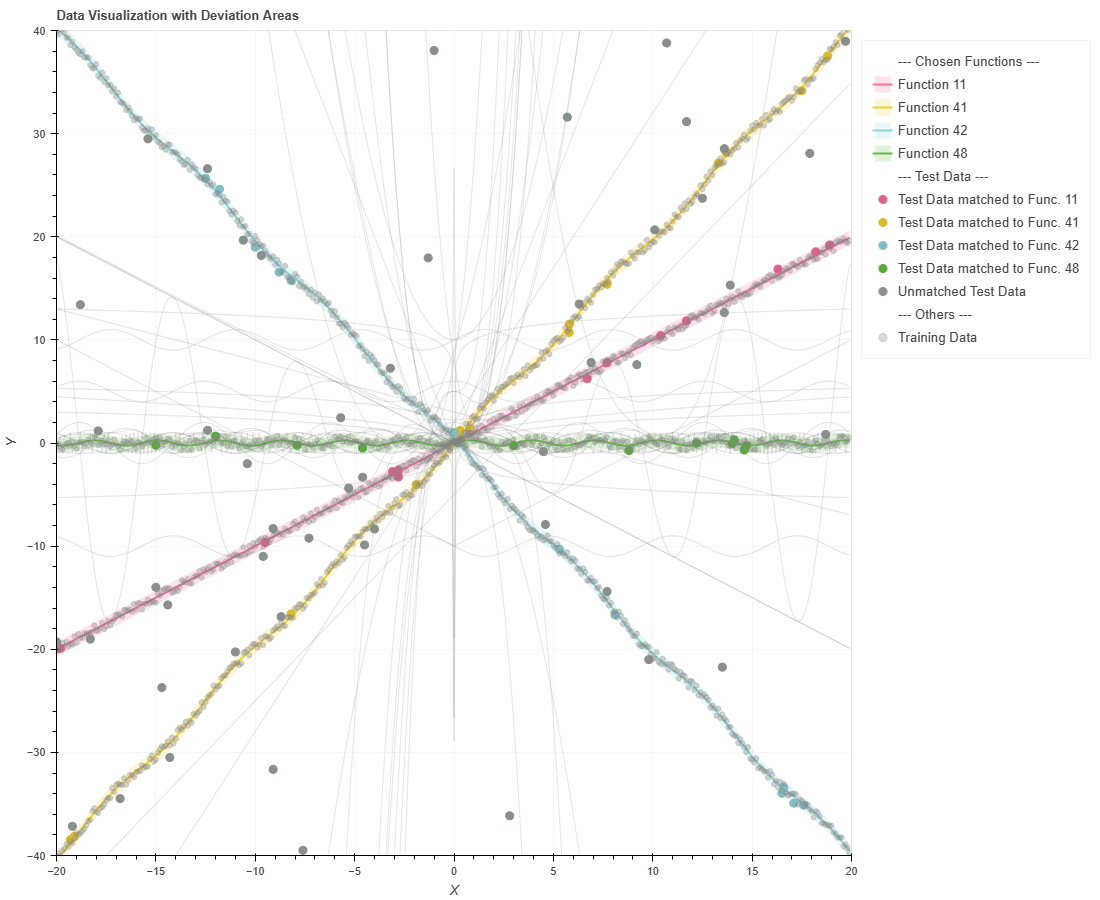

In [9]:
display(Image(filename="bokeh_plot.png"))

# Additional Task

The following commands are for a Windows OS and can be performed in the Windows `cmd`.


In [10]:
#### Clone the repository and checkout develop branch
#git clone https://github.com/WilliamRatz/PythonModule.git
#cd ./PythonModule
#git checkout develop

### After making changes (adding new function)
#git add .
#git commit -m "Added new function for X functionality"
#git push origin develop

### Then create a pull request (this is typically done through UI)